In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [2]:
product_revenue = con.execute("""
    SELECT
        i.product_id,
        t.product_category_name_english  AS category,
        COUNT(DISTINCT i.order_id)        AS orders,
        SUM(i.price)                      AS revenue,
        AVG(i.price)                      AS avg_price,
        SUM(i.freight_value)              AS total_freight
    FROM order_items i
    LEFT JOIN products p      USING (product_id)
    LEFT JOIN categories t    
        ON p.product_category_name = t.product_category_name
    GROUP BY i.product_id, t.product_category_name_english
    ORDER BY revenue DESC
""").df()

# Cumulative calculations
product_revenue["cumulative_revenue"] = product_revenue["revenue"].cumsum()
product_revenue["cumulative_pct"]     = (
    product_revenue["cumulative_revenue"] / product_revenue["revenue"].sum() * 100
)
product_revenue["product_rank"]       = range(1, len(product_revenue) + 1)
product_revenue["product_rank_pct"]   = (
    product_revenue["product_rank"] / len(product_revenue) * 100
)

# Find 80% threshold
idx_80 = (product_revenue["cumulative_pct"] >= 80).idxmax()
pct_products_for_80 = product_revenue.loc[idx_80, "product_rank_pct"]
n_products_for_80   = product_revenue.loc[idx_80, "product_rank"]

print(f"Total products : {len(product_revenue):,}")
print(f"Total revenue  : BRL {product_revenue['revenue'].sum():,.0f}")
print(f"\nPareto finding:")
print(f"  Top {pct_products_for_80:.1f}% of products ({n_products_for_80:,} products)")
print(f"  generate 80% of revenue")

Total products : 32,951
Total revenue  : BRL 13,591,644

Pareto finding:
  Top 25.9% of products (8,536 products)
  generate 80% of revenue


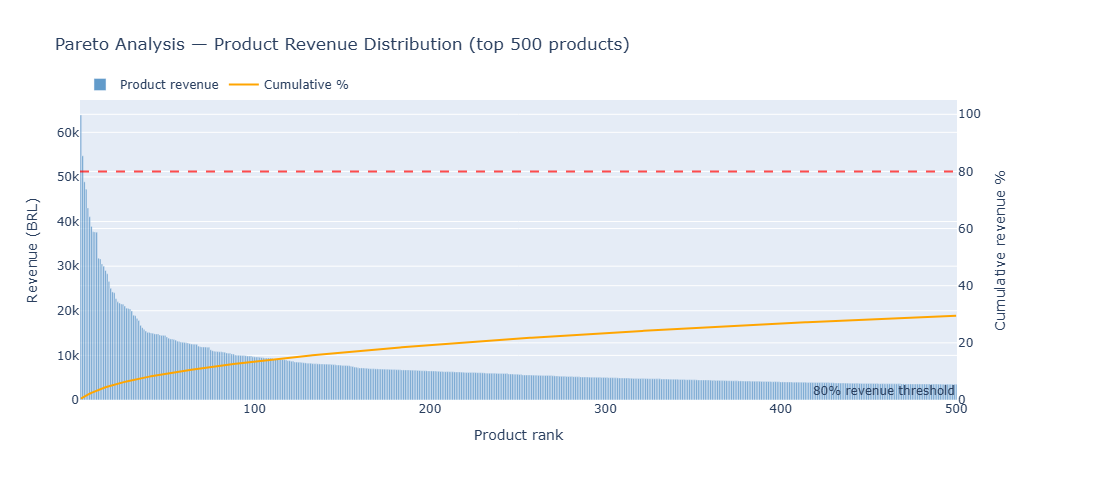

In [3]:
# Use top 500 products for readable chart
plot_df = product_revenue.head(500)

fig1 = make_subplots(specs=[[{"secondary_y": True}]])

fig1.add_trace(go.Bar(
    x=plot_df["product_rank"],
    y=plot_df["revenue"],
    name="Product revenue",
    marker_color="#2171b5",
    opacity=0.7
), secondary_y=False)

fig1.add_trace(go.Scatter(
    x=plot_df["product_rank"],
    y=plot_df["cumulative_pct"],
    name="Cumulative %",
    line=dict(color="orange", width=2),
    mode="lines"
), secondary_y=True)

# 80% reference line
fig1.add_hline(
    y=80, line_dash="dash",
    line_color="red", opacity=0.7,
    annotation_text="80% revenue threshold",
    annotation_position="top right",
    secondary_y=True
)

fig1.update_layout(
    title="Pareto Analysis — Product Revenue Distribution (top 500 products)",
    xaxis_title="Product rank",
    height=480,
    legend=dict(orientation="h", y=1.1)
)
fig1.update_yaxes(title_text="Revenue (BRL)", secondary_y=False)
fig1.update_yaxes(title_text="Cumulative revenue %",
                  secondary_y=True, range=[0, 105])
fig1.show()

In [6]:
category_revenue = con.execute("""
    SELECT
        COALESCE(t.product_category_name_english, 'Unknown') AS category,
        COUNT(DISTINCT i.order_id)   AS orders,
        SUM(i.price)                 AS revenue,
        AVG(i.price)                 AS avg_price,
        COUNT(DISTINCT i.product_id) AS unique_products
    FROM order_items i
    LEFT JOIN products p   USING (product_id)
    LEFT JOIN categories t 
        ON p.product_category_name = t.product_category_name
    GROUP BY category
    ORDER BY revenue DESC
""").df()

category_revenue["cumulative_revenue"] = category_revenue["revenue"].cumsum()
category_revenue["cumulative_pct"]     = (
    category_revenue["cumulative_revenue"] / category_revenue["revenue"].sum() * 100
)
category_revenue["cat_rank_pct"] = (
    pd.Series(range(1, len(category_revenue)+1)) / len(category_revenue) * 100
).values

idx_80_cat    = (category_revenue["cumulative_pct"] >= 80).idxmax()
n_cats_for_80 = idx_80_cat + 1
pct_cats_for_80 = category_revenue.loc[idx_80_cat, "cat_rank_pct"]

print(f"Total categories : {len(category_revenue)}")
print(f"\nCategory Pareto:")
print(f"  Top {pct_cats_for_80:.1f}% of categories ({n_cats_for_80} categories)")
print(f"  generate 80% of revenue")
print(f"\nTop 15 categories by revenue:")
print(category_revenue[["category","orders","revenue","avg_price"]]
      .head(15).to_string(index=False))

Total categories : 72

Category Pareto:
  Top 25.0% of categories (18 categories)
  generate 80% of revenue

Top 15 categories by revenue:
             category  orders    revenue  avg_price
        health_beauty    8836 1258681.34 130.163531
        watches_gifts    5624 1205005.68 201.135984
       bed_bath_table    9417 1036988.68  93.296327
       sports_leisure    7720  988048.97 114.344285
computers_accessories    6689  911954.32 116.513903
      furniture_decor    6449  729762.49  87.564494
           cool_stuff    3632  635290.85 167.357969
           housewares    5884  632248.66  90.788148
                 auto    3897  592720.11 139.957523
         garden_tools    3518  485256.46 111.630196
                 toys    3886  483946.60 117.548360
                 baby    2885  411764.89 134.344173
            perfumery    3162  399124.87 116.737312
            telephony    4199  323667.53  71.213978
     office_furniture    1273  273960.70 162.011059


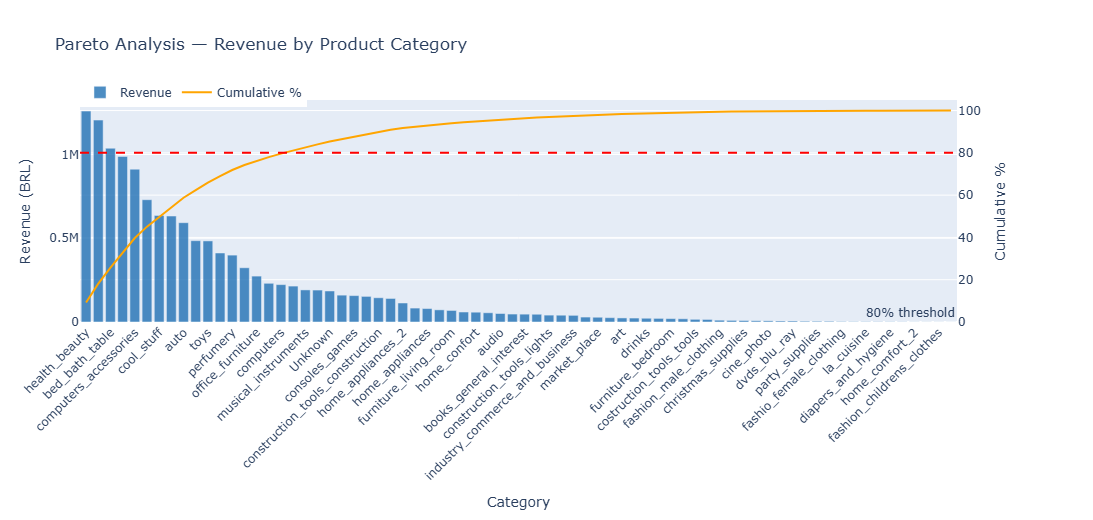

In [7]:
fig2 = make_subplots(specs=[[{"secondary_y": True}]])

fig2.add_trace(go.Bar(
    x=category_revenue["category"],
    y=category_revenue["revenue"],
    name="Revenue",
    marker_color="#2171b5",
    opacity=0.8
), secondary_y=False)

fig2.add_trace(go.Scatter(
    x=category_revenue["category"],
    y=category_revenue["cumulative_pct"],
    name="Cumulative %",
    line=dict(color="orange", width=2),
    mode="lines"
), secondary_y=True)

fig2.add_hline(
    y=80, line_dash="dash", line_color="red",
    annotation_text="80% threshold",
    annotation_position="top right",
    secondary_y=True
)

fig2.update_layout(
    title="Pareto Analysis — Revenue by Product Category",
    xaxis_title="Category",
    xaxis_tickangle=-45,
    height=520,
    legend=dict(orientation="h", y=1.1)
)
fig2.update_yaxes(title_text="Revenue (BRL)", secondary_y=False)
fig2.update_yaxes(title_text="Cumulative %", secondary_y=True, range=[0,105])
fig2.show()

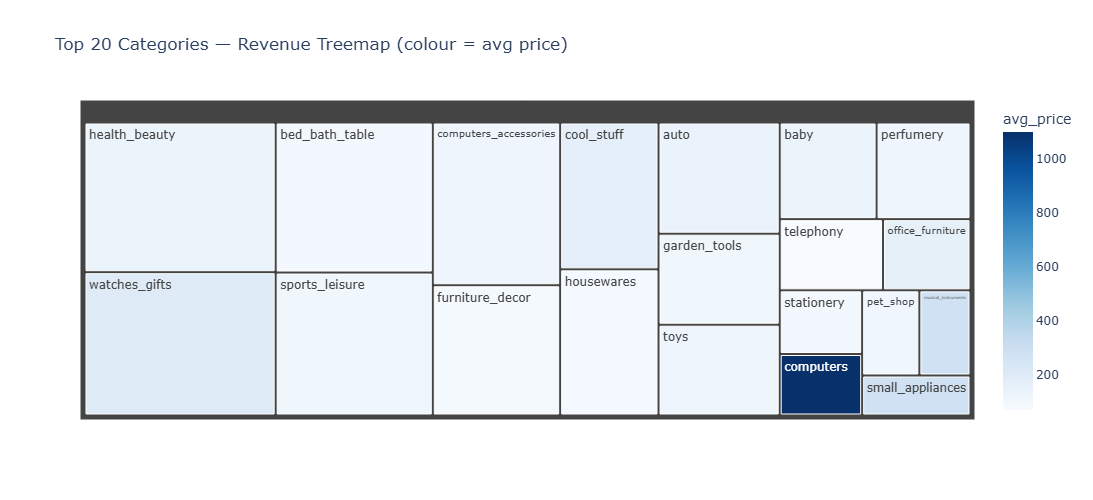

In [8]:
fig3 = px.treemap(
    category_revenue.head(20),
    path=["category"],
    values="revenue",
    color="avg_price",
    color_continuous_scale="Blues",
    title="Top 20 Categories — Revenue Treemap (colour = avg price)",
    hover_data={"orders": True, "avg_price": ":.2f"}
)
fig3.update_layout(height=500)
fig3.show()

In [9]:
seller_revenue = con.execute("""
    SELECT
        i.seller_id,
        s.seller_state,
        COUNT(DISTINCT i.order_id)  AS orders,
        SUM(i.price)                AS revenue,
        AVG(i.price)                AS avg_price,
        COUNT(DISTINCT i.product_id) AS unique_products
    FROM order_items i
    JOIN sellers s USING (seller_id)
    GROUP BY i.seller_id, s.seller_state
    ORDER BY revenue DESC
""").df()

seller_revenue["cumulative_revenue"] = seller_revenue["revenue"].cumsum()
seller_revenue["cumulative_pct"]     = (
    seller_revenue["cumulative_revenue"] / seller_revenue["revenue"].sum() * 100
)
seller_revenue["seller_rank_pct"] = (
    pd.Series(range(1, len(seller_revenue)+1)) / len(seller_revenue) * 100
).values

idx_80_sel    = (seller_revenue["cumulative_pct"] >= 80).idxmax()
n_sels_for_80 = idx_80_sel + 1
pct_sels_for_80 = seller_revenue.loc[idx_80_sel, "seller_rank_pct"]

print(f"Total sellers  : {len(seller_revenue):,}")
print(f"\nSeller Pareto:")
print(f"  Top {pct_sels_for_80:.1f}% of sellers ({n_sels_for_80} sellers)")
print(f"  generate 80% of revenue")
print(f"\nTop 10 sellers:")
print(seller_revenue[["seller_id","seller_state","orders","revenue"]]
      .head(10).to_string(index=False))

Total sellers  : 3,095

Seller Pareto:
  Top 17.6% of sellers (544 sellers)
  generate 80% of revenue

Top 10 sellers:
                       seller_id seller_state  orders   revenue
4869f7a5dfa277a7dca6462dcf3b52b2           SP    1132 229472.63
53243585a1d6dc2643021fd1853d8905           BA     358 222776.05
4a3ca9315b744ce9f8e9374361493884           SP    1806 200472.92
fa1c13f2614d7b5c4749cbc52fecda94           SP     585 194042.03
7c67e1448b00f6e969d365cea6b010ab           SP     982 187923.89
7e93a43ef30c4f03f38b393420bc753a           SP     336 176431.87
da8622b14eb17ae2831f4ac5b9dab84a           SP    1314 160236.57
7a67c85e85bb2ce8582c35f2203ad736           SP    1160 141745.53
1025f0e2d44d7041d6cf58b6550e0bfa           SP     915 138968.55
955fee9216a65b617aa5c0531780ce60           SP    1287 135171.70
